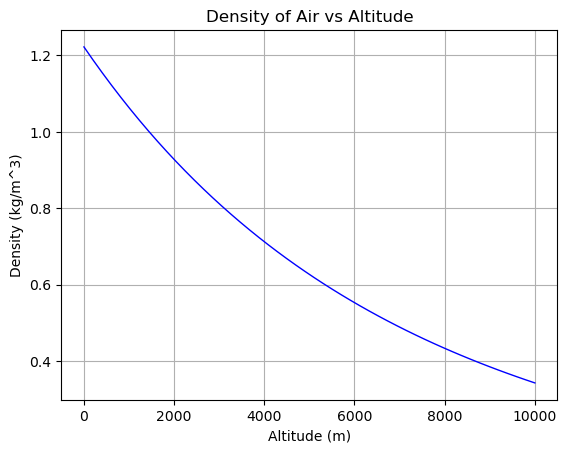

In [2]:
#initializing atmospheres and thermodynamics conditions
#note all the unit used here are SI, under m, s, kg, K,Pa, J etc. 

import numpy as np
import matplotlib.pyplot as plt 
def atmosph(altitude):
    #key assumption here: ideal gas condition in the troposphere on low altitude flight testing, and temperature decreases linearly with rate L 
    #equation used here;
    T_0 = 288.15
    L = -0.0065
    g = 9.81
    R = 8.3145
    p_0 = 101325
    M = 0.0289
    RL = R * M
    T = T_0 - L * altitude #linear temperature formula 
    p = p_0*(T / T_0)**(g*M / (RL)) #from the barometric formula relating temperature to pressure
    rho = p*M/ (R * T) #ideal gas relation 

    return T, p, rho

#plot of rho v altitude 
#troposphere is the lowest layer of the atmosphere, and it extends from the Earth's surface to an average altitude of about 12 km (7.5 miles).
# The temperature in the troposphere decreases with altitude at an average rate of about 6.5 degrees Celsius per kilometer 
T_0 = 288.15
L = -0.0065
g = 9.81
R = 8.3144621
p_0 = 101325
M = 0.0289
x=np.linspace(0,10000)
y = (p_0*M)/(R*T_0)*(1-L*x/T_0)**(g*M/(R*L)-1)
plt.xlabel('Altitude (m)')
plt.ylabel('Density (kg/m^3)')
plt.title('Density of Air vs Altitude')
plt.grid()   
plt.plot(x, y, color="blue", linewidth=1.0, linestyle="-")



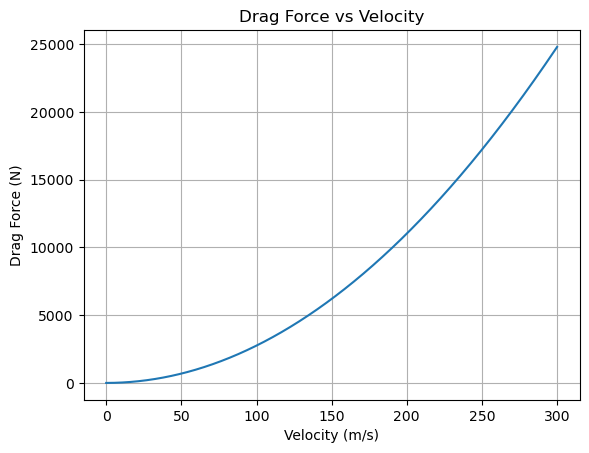

In [10]:
#aerodynamic forces calculation
"""
using the common aerodynamic force equations derived from Newton's laws, we can calculate the lift and drag forces acting on an aircraft. 
 The lift force is generated by the pressure difference between the upper and lower surfaces of the wing, 
 while the drag force is caused by the resistance of the air to the motion of the aircraft.
 
 The following my own understand of how the fluid dynamics and aerodynamics work, and the equations used here are based on the fundamental principles of fluid mechanics and aerodynamics:
 
 resultant force developed on the wing can be determined by integrating the pressure distribution over the surface of the wing. From there we can take the vertical 
 and horizontal components of the resultant force to determine the lift and drag forces respectively, from which we can derive the equation(with Bernoulli) in terms of the lift and drag coefficients. 
 The lift and drag coefficients are dimensionless quantities that describe the lift and drag forces acting on an aircraft relative to the air density, velocity, and wing area, it is 
 specfic to the shape and configuration of the aircraft, and can be determined experimentally or through computational fluid dynamics simulations.
"""
def lift(rho, v, wing_area, lc):
    return 0.5 * rho * v**2 * wing_area * lc

def drag(rho, v, wing_area, dc):
    return 0.5 * rho * v**2 * wing_area * dc

#dc = k * lc**2 + dc_0
#k - induced drag factor, which is a function of the aspect ratio of the wing and the oswald efficiency factor.
#dc_0 - zero lift drag coefficient, which is the drag coefficient when the lift coefficient is zero.


#force depends on V^2 here because of equation for dynamic pressure of the fluid.
'''
 Some question to thing about to understand this model is: 
 
Q: Why does induced drag increase with lc^2? 
Ans: Because increasing lift means the vortices generate at the wing tip is stronger and it also increases the angle at which the flow is deflected downwards, so these two effects stacks up.
Q: Why does drag initially decrease with speed? 
Ans: Because at low speeds, the drag is dominated by friction and form drag,
which decrease with increasing speed. However, as speed increases, the drag becomes dominated by wave drag and induced drag, which increase along with speed.
'''
#generating aerospace graph
import matplotlib.pyplot as plt
import numpy as np

#drag over a range of velocities
velocities = np.linspace(0, 300, 1000)
#assuming constant values for rho, wing_area, and dc
rho = 1.225  # air density at sea level in kg/m^3
wing_area = 10.0  # wing area in m^2
lc = 0.5  # lift coefficient
dc_0 = 0.02  # zero lift drag coefficient
k = 0.1  # induced drag factor
dc = k * lc**2 + dc_0  # total drag coefficient 0.045
drag_forces = drag(rho, velocities, wing_area, dc)

#plotting the drag forces
plt.plot(velocities, drag_forces)
plt.xlabel('Velocity (m/s)')
plt.ylabel('Drag Force (N)')
plt.title('Drag Force vs Velocity')
plt.grid(True)
plt.show()


In [ ]:
#add aircraft data set for plotting of the model here, probably using a data file, json or csv, and then use pandas to read the data and plot it using matplotlib.
#skips temporarily, will add later.


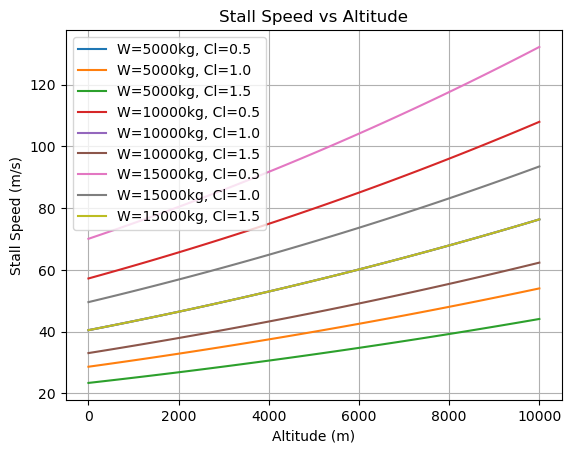

In [8]:
#in aerospace stalling is a condition in which the angle of attack of an aircraft's wing exceeds the critical angle, causing a sudden loss of lift and an increase in drag.
#calculation of stall speed, which is the minimum speed at which an aircraft can maintain level flight without stalling.
'''
The maths used here is that, cl is max at stall and in a steady level flight lift = weight, so we can derive the stall speed from the lift equation.
W(weight) = mg = 1/2 * rho * V^2 * wing_area * cl
therefore V = sqrt(2 * W / (rho * wing_area * cl))
'''

T_0 = 288.15
L = -0.0065
g = 9.81
R = 8.3144621
p_0 = 101325
M = 0.0289

def stall_speed(W, wing_area, lc):
    rho = (p_0*M)/(R*T_0)*(1-L*x/T_0)**(g*M/(R*L)-1) # borrowing the equation from previous section
    return np.sqrt(2 * W / (rho * wing_area * lc))

#altitude, weight and cl can vary, so we can plot the stall speed over a range of altitudes, weights and cl values.
x = np.linspace(0, 10000, 100)  # altitude in meters
weights = [5000, 10000, 15000]  # weights in kg
cl_values = [0.5, 1.0, 1.5]
for W in weights:
    for lc in cl_values:
        stall_speeds = stall_speed(W, 10.0, lc)  # assuming a constant wing area of 10 m^2
        plt.plot(x, stall_speeds, label=f'W={W}kg, Cl={lc}')
plt.xlabel('Altitude (m)')
plt.ylabel('Stall Speed (m/s)')
plt.title('Stall Speed vs Altitude')
plt.legend()
plt.grid(True)
plt.show()


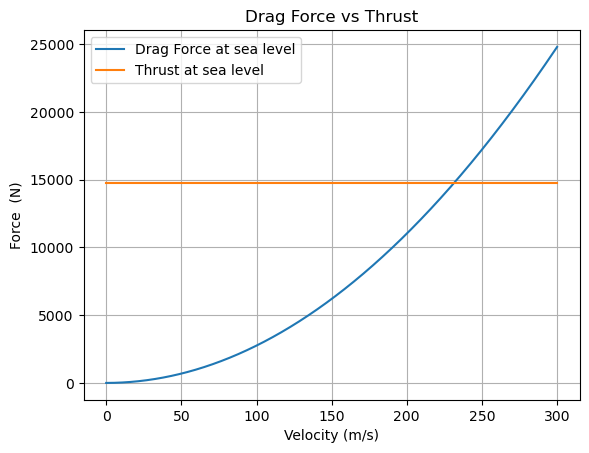

In [9]:
#now introduce propulsion system 
#for simplicity, I will not try to model a turbofan engine, which the most common type of engine used in commercial aircraft, 
# I will instead use a simpler thrust model 

# Thrust model: T = T(h, V, throttle), where h is altitude, V is velocity, and throttle is the throttle setting (0 to 1).
#approximatino model used here is the than T is modelled with a decrease with higher altitude.

'''
Throttle setting is a value between 0 and 1, it means that the engine is running at a certain percentage of its maximum thrust. From first principle in Newton's law, we can arrive at the result
that thrust is momentum flux and is therefore proportional to the density of air. Therefore the equation of approximation here is that thrust is T is proportional to rho(h)/rho_0

'''

T_0 = 147500
L = -0.0065
g = 9.81
R = 8.3144621
p_0 = 101325
M = 0.0289
rho_0 = p_0*M/(R*T_0) #density of air at sea level
def thrust(h, thro):
    rho = (p_0*M)/(R*T_0)*(1-L*x/T_0)**(g*M/(R*L)-1) #import the model from before
    T = T_0 *(rho/rho_0) * thro  #T_0 is the max thrust at sea level and rho_0 is the density of air at sea level
    return T

#The value of T_0 of course differ for different engines, for the sake of the argument we can take a range of value of T_0


#drag vs thrust 
"based on the previous description on drag and how that is related to V, "
"we used the functions defined on drag first then generate a plot of that against Thrust"

import matplotlib.pyplot as plt
import numpy as np

rho = 1.225 #density/height is controlled here 
x = np.linspace(0, 300, 1000)
thro = 0.1
T_0 =  147500#max thrust of plane prototype
y = T_0 * thro * np.ones((1000,1))#here height is controlled, 
#and we can change the value of thro to see how the thrust changes with different throttle settings.


plt.plot(x, drag_forces, label= f"Drag Force at sea level")
plt.plot(x, y, label = f"Thrust at sea level")
plt.xlabel('Velocity (m/s)')
plt.ylabel('Force  (N)')
plt.title('Drag Force vs Thrust')
plt.legend()
plt.grid(True)
plt.show()

